# Loss Compare 24

        这个 notebook 用来对比 Slurm job `24` 的实验结果：

        1. `loss_mse_24`: MSE loss
2. `loss_huber_24`: Huber loss
3. `loss_rel_24`: relative-error loss

        结果会自动从 `runs/` 下匹配对应的 run 目录，并读取：

        - `config.json`
        - `fig/metrics.json`
        - `fig/preds.npz`

        若历史结果没有把 `mc_weight` 写入 `preds.npz`，notebook 会根据 `config.json` 自动重建测试集事件权重，然后统一重算：

        - `resolution_weighted`
        - `logRMS_weighted`
        - `bias_weighted`


## 1. 设置路径并导入当前项目代码

这一格只做环境准备：定位项目根目录、输出目录，并导入当前整理后的 `src/common` 工具函数。


In [1]:
from pathlib import Path
import json
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import uproot
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path('/home/server/projects/energy_reconstruction')
NOTEBOOK_DIR = PROJECT_ROOT / 'notebook'
OUTPUT_DIR = NOTEBOOK_DIR / 'generated' / 'loss_compare_24'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common.utils import _weighted_mean, _weighted_std, _weighted_rms

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUTPUT_DIR   =', OUTPUT_DIR)


PROJECT_ROOT = /home/server/projects/energy_reconstruction
OUTPUT_DIR   = /home/server/projects/energy_reconstruction/notebook/generated/loss_compare_24


## 2. 自动发现 run 目录并检查结果文件

这里通过 `runs/` 下的目录名自动匹配本次对比实验，而不是手工抄路径。


In [2]:
RUN_GLOB = 'loss_*_24'
DISPLAY_NAME_MAP = {'loss_mse_24': 'MSE loss', 'loss_huber_24': 'Huber loss', 'loss_rel_24': 'Relative-error loss'}
ORDERED_RUN_NAMES = ['loss_mse_24', 'loss_huber_24', 'loss_rel_24']

candidate_dirs = sorted((PROJECT_ROOT / 'runs').glob(RUN_GLOB))
run_dirs = [p for p in candidate_dirs if p.is_dir() and p.name in DISPLAY_NAME_MAP]

assert run_dirs, f'No run dirs matched pattern: {RUN_GLOB}'
missing_expected = [name for name in ORDERED_RUN_NAMES if not (PROJECT_ROOT / 'runs' / name).exists()]
assert not missing_expected, f'Missing expected runs: {missing_expected}'

RESULTS = {}
for run_name in ORDERED_RUN_NAMES:
    run_dir = PROJECT_ROOT / 'runs' / run_name
    fig_dir = run_dir / 'fig'
    config_path = run_dir / 'config.json'
    metrics_path = fig_dir / 'metrics.json'
    preds_path = fig_dir / 'preds.npz'

    assert run_dir.exists(), f'Missing run dir: {run_dir}'
    assert config_path.exists(), f'Missing config: {config_path}'
    assert metrics_path.exists(), f'Missing metrics: {metrics_path}'
    assert preds_path.exists(), f'Missing preds: {preds_path}'

    RESULTS[run_name] = {
        'display': DISPLAY_NAME_MAP[run_name],
        'run_dir': run_dir,
        'config_path': config_path,
        'metrics_path': metrics_path,
        'preds_path': preds_path,
    }

for run_name, item in RESULTS.items():
    print(run_name)
    print('  config :', item['config_path'])
    print('  metrics:', item['metrics_path'])
    print('  preds  :', item['preds_path'])


loss_mse_24
  config : /home/server/projects/energy_reconstruction/runs/loss_mse_24/config.json
  metrics: /home/server/projects/energy_reconstruction/runs/loss_mse_24/fig/metrics.json
  preds  : /home/server/projects/energy_reconstruction/runs/loss_mse_24/fig/preds.npz
loss_huber_24
  config : /home/server/projects/energy_reconstruction/runs/loss_huber_24/config.json
  metrics: /home/server/projects/energy_reconstruction/runs/loss_huber_24/fig/metrics.json
  preds  : /home/server/projects/energy_reconstruction/runs/loss_huber_24/fig/preds.npz
loss_rel_24
  config : /home/server/projects/energy_reconstruction/runs/loss_rel_24/config.json
  metrics: /home/server/projects/energy_reconstruction/runs/loss_rel_24/fig/metrics.json
  preds  : /home/server/projects/energy_reconstruction/runs/loss_rel_24/fig/preds.npz


## 3. 读取 `config.json`、`metrics.json` 和 `preds.npz`

这一步不手工抄数据，直接从结果文件自动读取。若 `preds.npz` 已带 `mc_weight`，就直接使用。


In [3]:
loaded = {}
summary_rows = []

for run_name, item in RESULTS.items():
    with open(item['config_path'], 'r') as f:
        config = json.load(f)
    with open(item['metrics_path'], 'r') as f:
        metrics = json.load(f)
    preds = np.load(item['preds_path'])

    mc_weight = preds['mc_weight'].astype(np.float64) if 'mc_weight' in preds.files else None

    loaded[run_name] = {
        'display': item['display'],
        'config': config,
        'metrics': metrics,
        'logE_true': preds['logE_true'].astype(np.float64),
        'logE_pred': preds['logE_pred'].astype(np.float64),
        'mc_weight': mc_weight,
    }

    summary_rows.append({
        'experiment': item['display'],
        'run_name': run_name,
        'n': metrics.get('n'),
        'w_log_sigma': metrics.get('w_log_sigma'),
        'w_log_rmse': metrics.get('w_log_rmse'),
        'w_log_bias': metrics.get('w_log_bias'),
        'has_mc_weight': mc_weight is not None,
    })

for row in summary_rows:
    print(row)


{'experiment': 'MSE loss', 'run_name': 'loss_mse_24', 'n': 424903, 'w_log_sigma': 0.21507544030777037, 'w_log_rmse': 0.2152922433235156, 'w_log_bias': -0.009659447709481489, 'has_mc_weight': True}
{'experiment': 'Huber loss', 'run_name': 'loss_huber_24', 'n': 424903, 'w_log_sigma': 0.21524692083035507, 'w_log_rmse': 0.2152801165718545, 'w_log_bias': -0.0037804241027993945, 'has_mc_weight': True}
{'experiment': 'Relative-error loss', 'run_name': 'loss_rel_24', 'n': 424903, 'w_log_sigma': 0.2305574646165893, 'w_log_rmse': 0.2690962075094609, 'w_log_bias': -0.13876608003746754, 'has_mc_weight': True}


## 4. 必要时重建历史结果的 `mc_weight`

一些早期 run 的 `preds.npz` 没有保存 `mc_weight`。这种情况下，这一格会按照历史 `config.json` 自动重建 test split，
并从原始 ROOT 数据里按相同 event-level cuts 提取 `mc_weight`。重建完成后，会校验 `logE_true` 与历史 `preds.npz` 是否严格对齐。


In [4]:
def _fallback(x, y):
    return y if x is None else x

def build_eval_cuts(config):
    core_box = _fallback(config.get('eval_core_box'), config.get('core_box'))
    return {
        'Emin': _fallback(config.get('eval_Emin'), config.get('Emin')),
        'Emax': _fallback(config.get('eval_Emax'), config.get('Emax')),
        'pinc_max': _fallback(config.get('eval_pinc_max'), config.get('pinc_max')),
        'dcedge_min': _fallback(config.get('eval_dcedge_min'), config.get('dcedge_min')),
        'dangle_max_rad': _fallback(config.get('eval_dangle_max_deg'), config.get('dangle_max_deg')) * np.pi / 180.0,
        'theta_max_rad': _fallback(config.get('eval_theta_max_deg'), config.get('theta_max_deg')) * np.pi / 180.0,
        'use_core_box': bool(config.get('eval_use_core_box') or config.get('use_core_box', False)),
        'core_box': tuple(core_box),
        'vqsamp_ratio_min': _fallback(config.get('eval_vqsamp_ratio_min'), config.get('vqsamp_ratio_min')),
    }

def build_candidate_file_lists(config):
    root_path = Path(config['root_path'])
    entries = []
    for name in os.listdir(root_path):
        full = root_path / name
        if full.is_file():
            entries.append(full)

    candidates = []
    root_only = sorted([str(p) for p in entries if p.name.endswith('.root')])
    if root_only:
        candidates.append(('root_only', root_only[: config['n_files']]))

    all_files = sorted([str(p) for p in entries])
    if all_files:
        candidates.append(('all_files', all_files[: config['n_files']]))

    return candidates

def extract_test_logtrue_and_weights(test_files, cuts):
    branches = [
        'mc_energy', 'pincness', 'dcedge', 'mc_dangle', 'theta',
        'mc_xc', 'mc_yc', 'vqsamp', 'mc_weight'
    ]
    out_true = []
    out_weight = []

    for idx, file_path in enumerate(test_files, start=1):
        with uproot.open(file_path) as f:
            tree = f['t_eventout;1']
            arrays = tree.arrays(branches, library='np')

        n_total = len(arrays['mc_energy'])
        mask_evt = np.ones(n_total, dtype=bool)

        Emin = cuts.get('Emin')
        if Emin is not None:
            mask_evt &= (arrays['mc_energy'] > float(Emin))

        Emax = cuts.get('Emax')
        if Emax is not None:
            mask_evt &= (arrays['mc_energy'] < float(Emax))

        pinc_max = cuts.get('pinc_max')
        if pinc_max is not None:
            mask_evt &= (arrays['pincness'] < float(pinc_max))

        dangle_max_rad = cuts.get('dangle_max_rad')
        if dangle_max_rad is not None:
            mask_evt &= (arrays['mc_dangle'] < float(dangle_max_rad))

        theta_max_rad = cuts.get('theta_max_rad')
        if theta_max_rad is not None:
            mask_evt &= (arrays['theta'] < float(theta_max_rad))

        dcedge_min = cuts.get('dcedge_min')
        if dcedge_min is not None:
            mask_evt &= (arrays['dcedge'] > float(dcedge_min))

        use_core_box = bool(cuts.get('use_core_box', False))
        if use_core_box:
            xmin, xmax, ymin, ymax = cuts.get('core_box', (-130.0, 130.0, -110.0, 110.0))
            mask_evt &= (
                (arrays['mc_xc'] >= xmin) & (arrays['mc_xc'] <= xmax)
                & (arrays['mc_yc'] >= ymin) & (arrays['mc_yc'] <= ymax)
            )

        vqsamp_ratio_min = cuts.get('vqsamp_ratio_min')
        if vqsamp_ratio_min is not None:
            vqsamp = arrays['vqsamp']
            ratios = np.array([
                (np.count_nonzero(v > 0) / len(v)) if len(v) > 0 else 0.0
                for v in vqsamp
            ], dtype=np.float32)
            mask_evt &= (ratios >= float(vqsamp_ratio_min))

        out_true.append(np.log10(arrays['mc_energy'][mask_evt]).astype(np.float64))
        out_weight.append(arrays['mc_weight'][mask_evt].astype(np.float64))

        if idx % 250 == 0 or idx == len(test_files):
            print(f'  processed {idx} / {len(test_files)} test files')

    return np.concatenate(out_true), np.concatenate(out_weight)

def reconstruct_missing_weights(reference_run_name):
    ref = loaded[reference_run_name]
    config = ref['config']
    target_log_true = ref['logE_true']
    cuts = build_eval_cuts(config)

    for candidate_name, root_files in build_candidate_file_lists(config):
        print(f'trying file-list candidate: {candidate_name} ({len(root_files)} files)')
        train_files, test_files = train_test_split(
            root_files,
            test_size=config['test_size'],
            random_state=config['seed'],
        )
        train_files, val_files = train_test_split(
            train_files,
            test_size=config['val_size'],
            random_state=config['seed'],
        )
        print(f'  split sizes: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}')

        try:
            rebuilt_log_true, rebuilt_weight = extract_test_logtrue_and_weights(test_files, cuts)
        except Exception as exc:
            print(f'  candidate failed while reading files: {type(exc).__name__}: {exc}')
            continue

        same_len = len(rebuilt_log_true) == len(target_log_true)
        same_values = same_len and np.allclose(rebuilt_log_true, target_log_true)
        print(f'  alignment: same_len={same_len}, same_values={same_values}')

        if same_values:
            return rebuilt_weight

    raise RuntimeError('Failed to reconstruct mc_weight aligned with stored preds.npz')

if any(item['mc_weight'] is None for item in loaded.values()):
    reference_run_name = next(name for name in ORDERED_RUN_NAMES if loaded[name]['mc_weight'] is None)
    rebuilt_weight = reconstruct_missing_weights(reference_run_name)
    for run_name in ORDERED_RUN_NAMES:
        if loaded[run_name]['mc_weight'] is None:
            assert len(rebuilt_weight) == len(loaded[run_name]['logE_true'])
            loaded[run_name]['mc_weight'] = rebuilt_weight.copy()
            print(f'filled mc_weight for {run_name} from reconstructed test-set weights')
else:
    print('All runs already contain mc_weight in preds.npz')


All runs already contain mc_weight in preds.npz


## 5. 用共享 true-energy bins 重算三条 weighted 曲线

这里统一使用 `preds.npz` 中的 `logE_true`、`logE_pred`、`mc_weight`，并按 `src/common.utils` 中相同的加权统计定义重算对比曲线。


In [5]:
def compute_weighted_curves(log_true, log_pred, weights, bin_edges):
    mask = (
        np.isfinite(log_true)
        & np.isfinite(log_pred)
        & np.isfinite(weights)
        & (weights > 0)
    )

    log_true = log_true[mask]
    log_pred = log_pred[mask]
    weights = weights[mask]

    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bias = []
    resolution = []
    log_rms = []

    for i in range(len(bin_edges) - 1):
        m = (log_true >= bin_edges[i]) & (log_true < bin_edges[i + 1])
        if m.sum() > 10:
            residual = log_pred[m] - log_true[m]
            w = weights[m]
            bias.append(float(_weighted_mean(residual, w)))
            resolution.append(float(_weighted_std(log_pred[m], w)))
            log_rms.append(float(_weighted_rms(residual, w)))
        else:
            bias.append(np.nan)
            resolution.append(np.nan)
            log_rms.append(np.nan)

    return {
        'bin_centers': centers,
        'bias': np.asarray(bias, dtype=np.float64),
        'resolution': np.asarray(resolution, dtype=np.float64),
        'log_rms': np.asarray(log_rms, dtype=np.float64),
    }

all_true = []
for item in loaded.values():
    mask = np.isfinite(item['logE_true'])
    all_true.append(item['logE_true'][mask])

all_true = np.concatenate(all_true)
bin_edges = np.linspace(all_true.min(), all_true.max(), 21)

curves = {}
for run_name, item in loaded.items():
    curves[run_name] = compute_weighted_curves(
        item['logE_true'],
        item['logE_pred'],
        item['mc_weight'],
        bin_edges,
    )

print('shared true-energy range =', (float(all_true.min()), float(all_true.max())))
print('number of bins          =', len(bin_edges) - 1)


shared true-energy range = (2.0000205039978027, 5.999189853668213)
number of bins          = 20


## 6. 统一绘图并导出图片

接下来三张图使用统一颜色、标记和图例风格，方便直接比较。


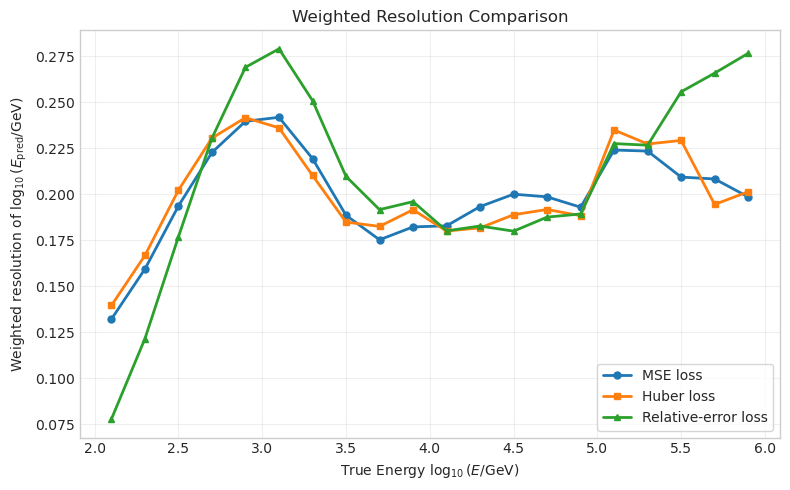

saved: /home/server/projects/energy_reconstruction/notebook/generated/loss_compare_24/resolution_weighted_compare_24.png


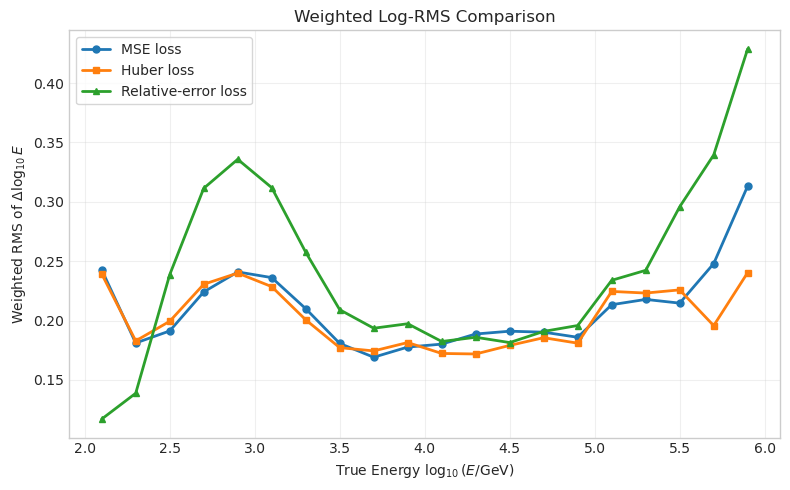

saved: /home/server/projects/energy_reconstruction/notebook/generated/loss_compare_24/logRMS_weighted_compare_24.png


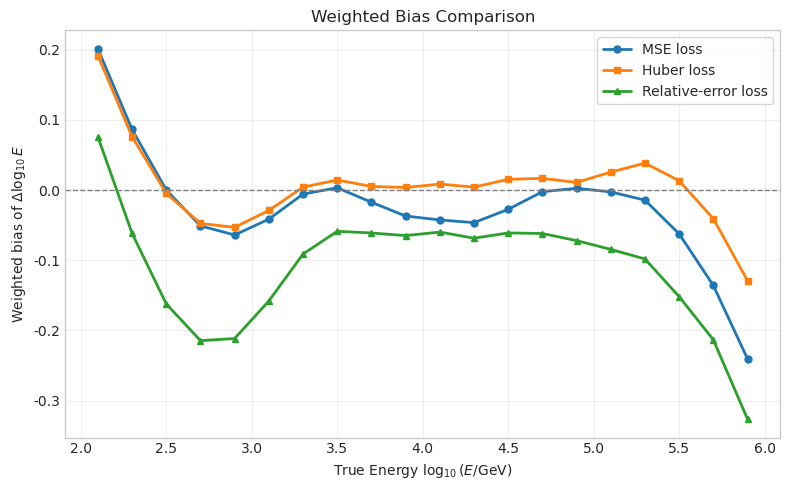

saved: /home/server/projects/energy_reconstruction/notebook/generated/loss_compare_24/bias_weighted_compare_24.png
generated files:
   /home/server/projects/energy_reconstruction/notebook/generated/loss_compare_24/resolution_weighted_compare_24.png
   /home/server/projects/energy_reconstruction/notebook/generated/loss_compare_24/logRMS_weighted_compare_24.png
   /home/server/projects/energy_reconstruction/notebook/generated/loss_compare_24/bias_weighted_compare_24.png


In [6]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
markers = ['o', 's', '^', 'D', 'v']
STYLE = {}
for idx, run_name in enumerate(ORDERED_RUN_NAMES):
    STYLE[run_name] = {
        'color': colors[idx % len(colors)],
        'marker': markers[idx % len(markers)],
    }

def plot_compare(metric_key, ylabel, title, filename, draw_zero=False):
    fig, ax = plt.subplots(figsize=(8, 5))
    for run_name in ORDERED_RUN_NAMES:
        item = loaded[run_name]
        curve = curves[run_name]
        style = STYLE[run_name]
        ax.plot(
            curve['bin_centers'],
            curve[metric_key],
            marker=style['marker'],
            color=style['color'],
            linewidth=2,
            markersize=5,
            label=item['display'],
        )

    if draw_zero:
        ax.axhline(0.0, color='gray', linestyle='--', linewidth=1)

    ax.set_xlabel(r'True Energy $\log_{10}(E/\mathrm{GeV})$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=True)
    ax.grid(alpha=0.3)
    fig.tight_layout()

    out_path = OUTPUT_DIR / filename
    fig.savefig(out_path, dpi=200)
    plt.show()
    print('saved:', out_path)
    return out_path

resolution_path = plot_compare(
    metric_key='resolution',
    ylabel=r'Weighted resolution of $\log_{10}(E_\mathrm{pred}/\mathrm{GeV})$',
    title='Weighted Resolution Comparison',
    filename='resolution_weighted_compare_24.png',
    draw_zero=False,
)

log_rms_path = plot_compare(
    metric_key='log_rms',
    ylabel=r'Weighted RMS of $\Delta\log_{10}E$',
    title='Weighted Log-RMS Comparison',
    filename='logRMS_weighted_compare_24.png',
    draw_zero=False,
)

bias_path = plot_compare(
    metric_key='bias',
    ylabel=r'Weighted bias of $\Delta\log_{10}E$',
    title='Weighted Bias Comparison',
    filename='bias_weighted_compare_24.png',
    draw_zero=True,
)

print('generated files:')
print('  ', resolution_path)
print('  ', log_rms_path)
print('  ', bias_path)
